
### Ziel dieser Datei
Daten etwas statistisch / mit Grafiken zeigen (nur für den Pitch, was Sinn macht)

### Datenquellen
* GeoJSON mit finalen Lagerplätzen aus Datei 2. Die TAbellen und Attribute daraus sollten genügen für diese Visualisierungen.

### Grober Codeaufbau
1. Flächenberechnung: Flächen der einzelnen Polygonen berechnen.
2. Aggregieren: Daten z.B. gruppieren oder auch nach Flächenart (Wald/Wiese) gruppieren etc. Diverse Vorbereitungen für Diagramme.
3. Diagramme zeichnen: Mit Matplotlib diverse Grafiken erstellen. (z.B. Balkendiagramm mit Top 5 Kantonen / Kreisidagramm Lagerflächen in Wald/Wiese / etc.)

### Export & Übernahme für die Nächste Datei 
* Diagramme als Bilddateien abspeichern um für Pitch-Präsentation zu verwenden.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ein schönes, professionelles Design für die Pitch-Grafiken setzen
plt.style.use('ggplot')
sns.set_palette("Set2")

# 1. Daten laden
print("Lade Daten für den Pitch...")
try:
    rohdaten = gpd.read_file("data_BL/bearbeitet_flaechen.geojson")
    finale_daten = gpd.read_file("output/geeignete_lagerflaechen_BL.geojson")
    print("Daten erfolgreich geladen!")
except FileNotFoundError as e:
    print(f"Fehler: {e}. Stelle sicher, dass die Dateien von Datei 1 und 2 generiert wurden.")

Lade Daten für den Pitch...
Daten erfolgreich geladen!


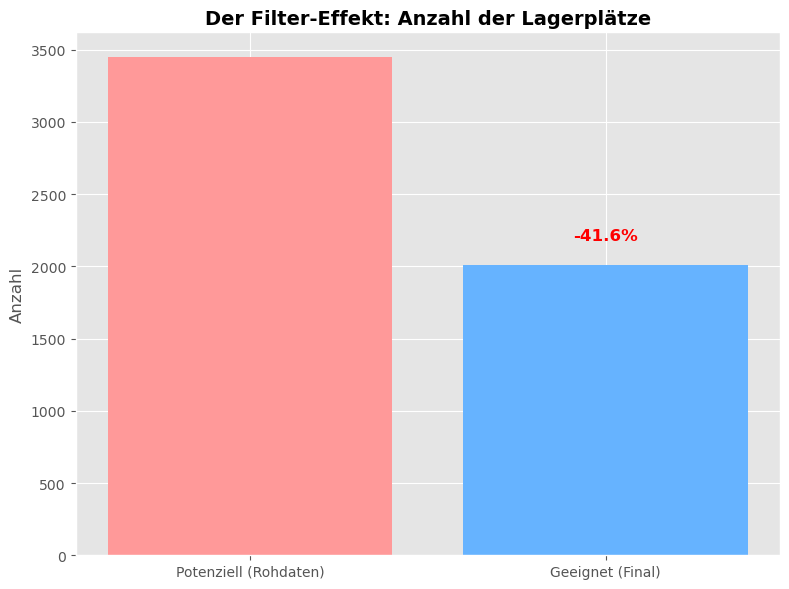

In [5]:
# 2. Vergleich Rohdaten vs. Finale Daten berechnen
anzahl_roh = len(rohdaten)
anzahl_final = len(finale_daten)

# 3. Das Vorher-Nachher Diagramm zeichnen (Nur Anzahl)
fig, ax = plt.subplots(figsize=(8, 6))

# Balkendiagramm: Anzahl Polygone
ax.bar(['Potenziell (Rohdaten)', 'Geeignet (Final)'], [anzahl_roh, anzahl_final], color=['#ff9999', '#66b3ff'])
ax.set_title('Der Filter-Effekt: Anzahl der Lagerplätze', fontweight='bold', fontsize=14)
ax.set_ylabel('Anzahl')

# Prozentualer Verlust als Text über dem zweiten Balken
verlust_prozent_anzahl = round((1 - anzahl_final/anzahl_roh)*100, 1)
ax.text(1, anzahl_final + (anzahl_roh*0.05), f"-{verlust_prozent_anzahl}%", ha='center', color='red', fontweight='bold', fontsize=12)

plt.tight_layout()

# Grafik für den Pitch speichern
plt.savefig('output/pitch_01_filter_effekt.png', dpi=300, bbox_inches='tight')
plt.show()

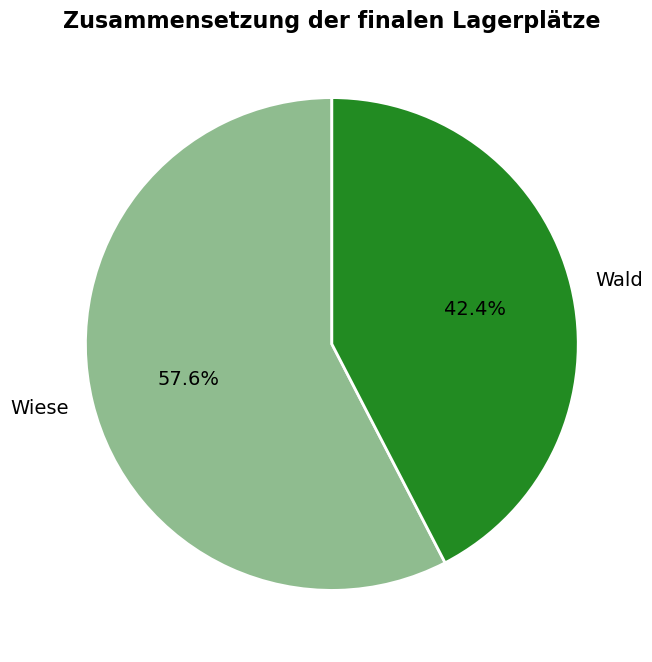

In [3]:
# 4. Verteilung Wald vs. Wiese
counts = finale_daten['landuse'].value_counts()

# Labels übersetzen für den Pitch
label_mapping = {'meadow': 'Wiese', 'forest': 'Wald'}
labels = [label_mapping.get(idx, idx) for idx in counts.index]

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(counts, 
       labels=labels, 
       autopct='%1.1f%%', 
       startangle=90, 
       colors=['#8FBC8F', '#228B22'], # Helles vs dunkles Grün
       wedgeprops={'edgecolor': 'white', 'linewidth': 2},
       textprops={'fontsize': 14})

ax.set_title('Zusammensetzung der finalen Lagerplätze', fontweight='bold', fontsize=16)

plt.savefig('output/pitch_02_wald_vs_wiese.png', dpi=300, bbox_inches='tight')
plt.show()

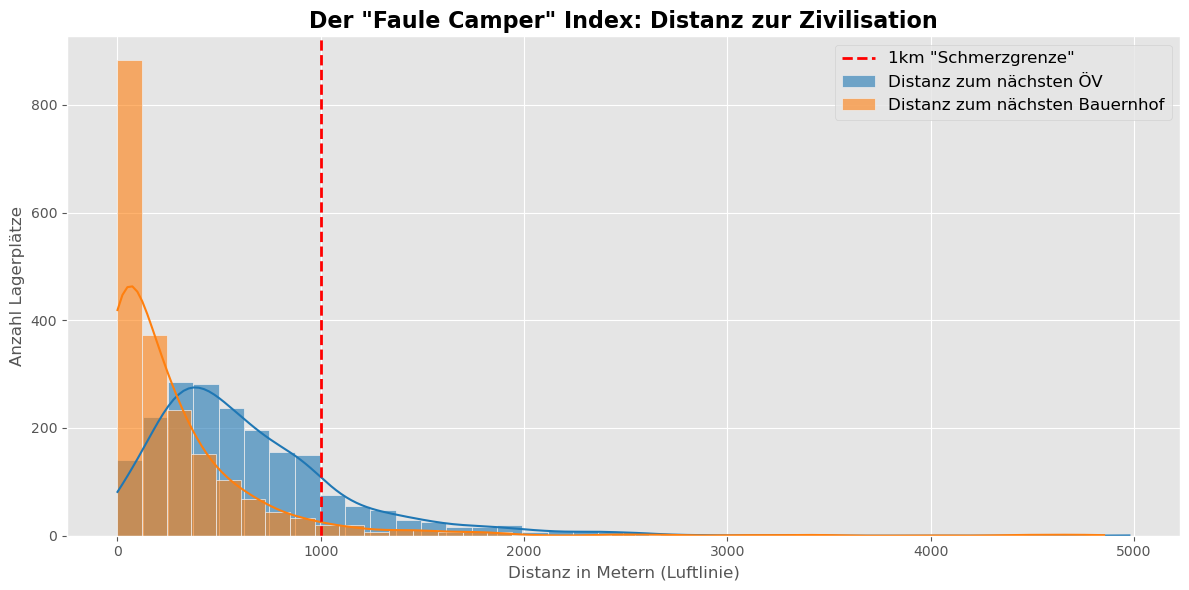

In [4]:
# 5. Distanzen analysieren (Histogramm)
fig, ax = plt.subplots(figsize=(12, 6))

# Wir blenden extreme Ausreisser aus (z.B. > 5km) für eine schönere Darstellung
max_dist = 5000 
daten_zoom = finale_daten[(finale_daten['dist_oev_m'] <= max_dist) & (finale_daten['dist_bauernhof_m'] <= max_dist)]

sns.histplot(daten_zoom['dist_oev_m'], bins=40, kde=True, color='#1f77b4', alpha=0.6, label='Distanz zum nächsten ÖV')
sns.histplot(daten_zoom['dist_bauernhof_m'], bins=40, kde=True, color='#ff7f0e', alpha=0.6, label='Distanz zum nächsten Bauernhof')

ax.set_title('Der "Faule Camper" Index: Distanz zur Zivilisation', fontweight='bold', fontsize=16)
ax.set_xlabel('Distanz in Metern (Luftlinie)', fontsize=12)
ax.set_ylabel('Anzahl Lagerplätze', fontsize=12)

# Eine fiktive Schmerzgrenze bei 1km einzeichnen (für den Pitch ein guter Aufhänger)
ax.axvline(x=1000, color='red', linestyle='--', linewidth=2, label='1km "Schmerzgrenze"')

ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('output/pitch_03_distanzen.png', dpi=300, bbox_inches='tight')
plt.show()